In [126]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix


In [127]:
df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
print("✅ 数据读取成功，共有行数:", len(df))
print("✅ 列名如下:")
print(df.columns.tolist())

✅ 数据读取成功，共有行数: 37053
✅ 列名如下:
['ID NR (anonymisert dummy)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'Bankkunde (1/0)', 'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET', 'BANK WALLET I MNOK', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mi

In [128]:
df = df.drop(columns=['Bankkunde (1/0)','SUM UTLÅN','SUM RAMME','SUM INNSKUDD','BANK WALLET','BANK WALLET I MNOK', 'ID NR (anonymisert dummy)'])
print(df.columns.tolist())
# 去除列名空格与特殊字符
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^0-9A-Za-z_]", "", regex=True)

# 替换 “ja/nei” 为 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})

# 将可能的目标列转换为数值
target_col = 'Har_ln_i_bank_alle_banker'
df[target_col] = df[target_col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0}).astype(float)

# 删除目标缺失值
df = df.dropna(subset=[target_col])
# 拆分 PRODUKSJON
df['PRODUKSJON_list'] = df['PRODUKSJON'].fillna("").apply(lambda x: [s.strip() for s in x.split(",") if s])

# MultiLabelBinarizer
mlb = MultiLabelBinarizer()
produksjon_encoded = pd.DataFrame(mlb.fit_transform(df['PRODUKSJON_list']),
                                  columns=mlb.classes_,
                                  index=df.index)

# 合并回 df
df = pd.concat([df, produksjon_encoded], axis=1)
df = df.drop(columns=['PRODUKSJON', 'PRODUKSJON_list'])
df = pd.get_dummies(df, columns=['Kommune', 'Fylke', 'Bransje'], drop_first=True)
mapping = {"30-90 dg": 1, "90 dg+": 2, "XS" : 0, "S": 1, "M": 2, "L": 3}
df['Misligholdstype_encoded'] = df['Misligholdstype'].map(mapping)
df['NY_tilskuddskategori_encoded'] = df['NY_tilskuddskategori'].map(mapping)
df = df.drop(columns=['Misligholdstype', 'NY_tilskuddskategori'])
df = df.fillna(0)
print(df)

# 输出基本信息
print(f"目标变量 '{target_col}' 值分布：")
print(df[target_col].value_counts())


['Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Subsidy Dependency Ratio', 'Production Concentration Index', 'Total Production Value(NOK)']
       Misligh

/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_10727/806583085.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})


In [129]:
X = df.drop(columns=[target_col]).values
y = df[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [130]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix

k = 250
threshold = 0.8
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# 转为相似度
similarities = 1 - distances
n = X_scaled.shape[0]
A = lil_matrix((n, n))

for i in range(n):
    for j, sim in zip(indices[i][1:], similarities[i][1:]):  # 跳过自己
        if sim > threshold:  # 可以加阈值
            A[i, j] = 1
            A[j, i] = 1
    if A[i].nnz == 0:
        j = indices[i][1]
        A[i, j] = 1
        A[j, i] = 1

In [131]:
degrees = np.array(A.sum(axis=1)).flatten()

print("每个节点的度：", degrees)
print("平均度：", degrees.mean())
print("度的标准差：", degrees.std())
print("中位度：", np.median(degrees))
print("最小度：", degrees.min())
print("最大度：", degrees.max())

每个节点的度： [ 23.  23.  23. ...   1.   1. 121.]
平均度： 73.52011982835398
度的标准差： 54.184582402579274
中位度： 70.0
最小度： 1.0
最大度： 299.0


In [132]:
edge_index, edge_attr = from_scipy_sparse_matrix(A)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.float)
)


In [133]:
print(data)
print(f"节点数：{data.num_nodes}")
print(f"边数：{data.num_edges}")

Data(x=[37053, 749], edge_index=[2, 2724141], y=[37053])
节点数：37053
边数：2724141


In [134]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGEModel(in_channels=X.shape[1], hidden=256, out_channels=8)

In [135]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]

model.eval()
with torch.no_grad():
    embeddings = model(X_tensor, edge_index_tensor).numpy()

for i in range(embeddings.shape[1]):
    df[f"gnn_emb_{i}"] = embeddings[:, i]

/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_10727/2390417786.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]


--- 1. 准备数据 ---
特征矩阵的初始形状: (37053, 757)
目标向量的形状: (37053,)

--- 1a. 检查并修复重复的列名 ---
发现重复的列名，正在进行重命名...
重复的列: ['Bier', 'Blomster', 'Egg', 'Frukt', 'Geit', 'Gress', 'Gris', 'Hest', 'Korn', 'Kylling', 'Melk', 'Potet', 'Sau', 'Storfe']
列名重命名完成。

--- 2. 划分数据集 ---
训练集大小: (33347, 757)
测试集大小: (3706, 757)

--- 3. 初始化并训练 CatBoost 模型 ---
0:	test: 0.5931404	best: 0.5931404 (0)	total: 15.4ms	remaining: 30.8s
100:	test: 0.6438400	best: 0.6439929 (99)	total: 1.01s	remaining: 19s
200:	test: 0.6508487	best: 0.6508487 (200)	total: 2.02s	remaining: 18.1s
300:	test: 0.6551688	best: 0.6552158 (299)	total: 3.06s	remaining: 17.3s
400:	test: 0.6566149	best: 0.6566662 (399)	total: 4.19s	remaining: 16.7s
500:	test: 0.6566685	best: 0.6567283 (401)	total: 5.37s	remaining: 16.1s
600:	test: 0.6583512	best: 0.6583602 (599)	total: 6.5s	remaining: 15.1s
700:	test: 0.6601134	best: 0.6601134 (700)	total: 7.63s	remaining: 14.1s
800:	test: 0.6596924	best: 0.6604693 (715)	total: 8.89s	remaining: 13.3s
900:	test: 0.6598302	be

/Users/zhaoweidong/miniconda3/envs/myenv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zhaoweidong/miniconda3/envs/myenv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zhaoweidong/miniconda3/envs/myenv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zhaoweidong/miniconda3/envs/myenv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zhaoweidong/miniconda3/envs/myenv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 36151 (\N{CJK UNIFIED IDEOGRAPH-8D37}) missing from font(s) DejaVu Sans.
  fig

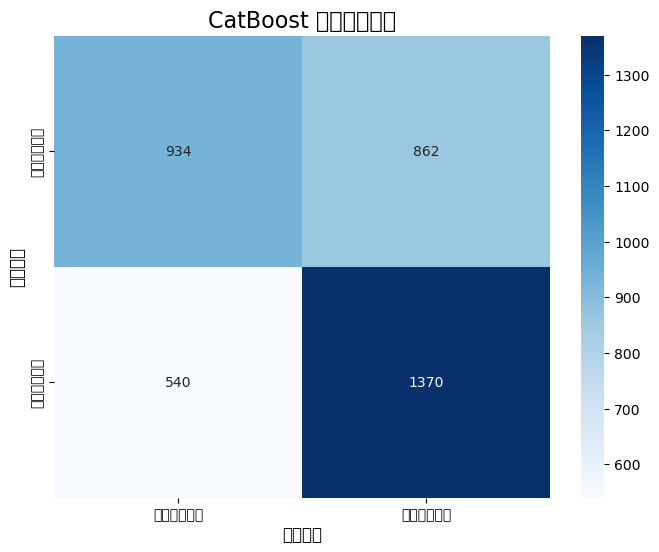


--- 5. 分析特征重要性 ---
CatBoost 模型特征重要性 (Top 20):
                                Feature Id  Importances
0   Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge     5.076387
1                Total_Production_ValueNOK     4.688037
2                                gnn_emb_2     3.833917
3                                gnn_emb_6     3.584990
4                            Produkiv_skog     3.508630
5                                gnn_emb_5     3.339193
6                                ENG_janei     3.255634
7                                gnn_emb_3     3.200847
8                                gnn_emb_0     3.130910
9                              Gress_dekar     3.106672
10                               gnn_emb_4     3.004633
11                          Tilskudd_i_USD     2.744776
12                               gnn_emb_7     2.699386
13                               gnn_emb_1     2.556467
14                         Fylke_Trøndelag     2.475983
15                Subsidy_Dependency_Ratio     2.473702
1

/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_10727/1229705151.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importances", y="Feature Id", data=feature_importance.head(20), palette="viridis")
/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_10727/1229705151.py:143: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_10727/1229705151.py:143: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_10727/1229705151.py:143: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/d84s8vcj4mndphc98_7b_m2r00

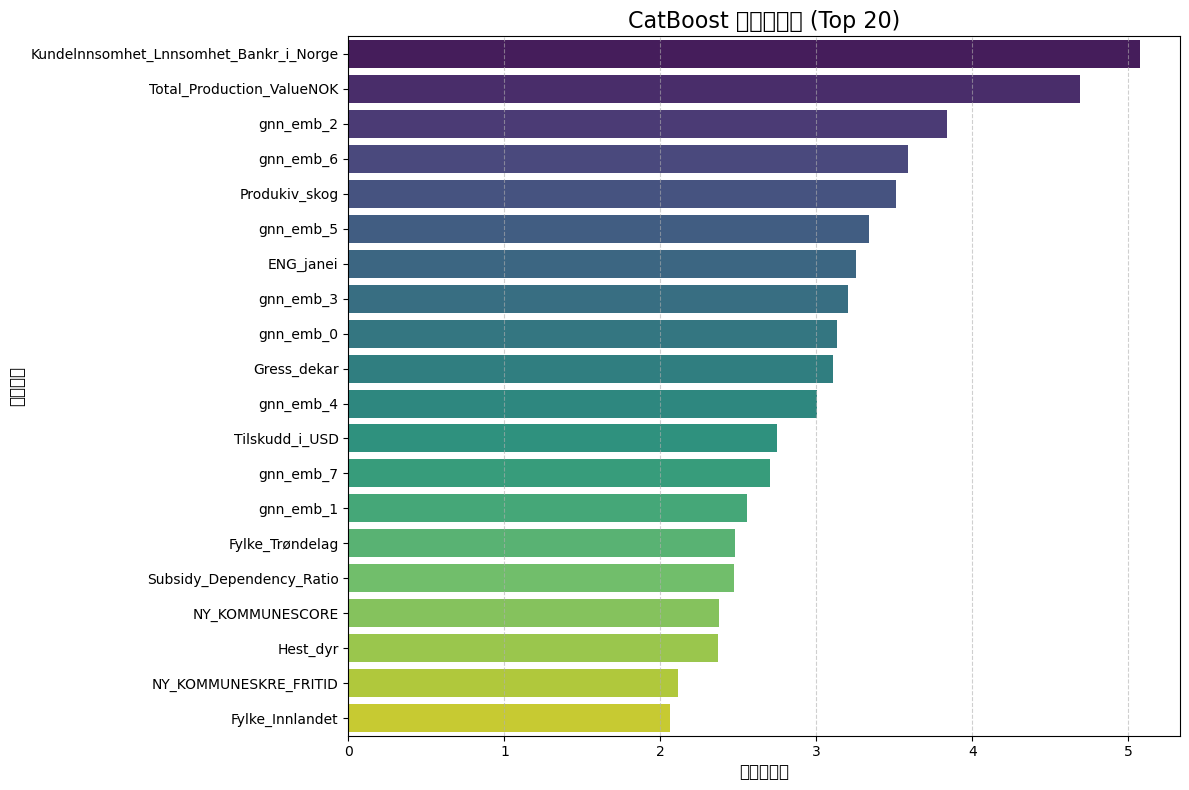

In [136]:
# 如果尚未安装 CatBoost 和 Seaborn 库，请取消下面的注释并运行
# !pip install catboost seaborn

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# 设置 matplotlib 支持中文显示
try:
    plt.rcParams['font.sans-serif'] = ['Heiti TC'] # 优先使用黑体
    plt.rcParams['axes.unicode_minus'] = False
except:
    try:
        plt.rcParams['font.sans-serif'] = ['SimHei'] # 如果没有黑体，尝试使用SimHei
        plt.rcParams['axes.unicode_minus'] = False
    except:
        print("未找到中文字体，图形中的中文可能无法正常显示。")


# --- 1. 准备最终数据集 ---
# 在上一步中，df 已经包含了原始特征和GNN生成的嵌入特征。
# 我们将使用这个增强后的 DataFrame 进行训练。
print("--- 1. 准备数据 ---")
target_col = 'Har_ln_i_bank_alle_banker'
X_final = df.drop(columns=[target_col])
y_final = df[target_col]

print(f"特征矩阵的初始形状: {X_final.shape}")
print(f"目标向量的形状: {y_final.shape}\n")


# --- 1a. 修复重复的列名 ---
# CatBoost要求所有特征名（列名）都是唯一的。我们的预处理步骤可能创建了重复的列名。
print("--- 1a. 检查并修复重复的列名 ---")
cols = pd.Series(X_final.columns)

if cols.duplicated().any():
    print("发现重复的列名，正在进行重命名...")
    duplicates = cols[cols.duplicated()].unique()
    print(f"重复的列: {list(duplicates)}")
    
    # 创建一个字典来追踪每个列名出现的次数
    col_counts = {}
    new_columns = []
    
    for col in X_final.columns:
        if col in col_counts:
            col_counts[col] += 1
            new_columns.append(f"{col}_{col_counts[col]}")
        else:
            col_counts[col] = 0
            new_columns.append(col)
    
    X_final.columns = new_columns
    print("列名重命名完成。\n")
else:
    print("未发现重复的列名。\n")


# --- 2. 划分训练集和测试集 ---
print("--- 2. 划分数据集 ---")
# 使用 stratify 参数确保训练集和测试集中的类别分布与原始数据集一致，这对于分类问题很重要。
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.1, random_state=42, stratify=y_final
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}\n")


# --- 3. 初始化并训练 CatBoost 模型 ---
print("--- 3. 初始化并训练 CatBoost 模型 ---")
# 初始化 CatBoostClassifier
model_cb = CatBoostClassifier(
    iterations=2000,          # 迭代次数（树的数量）
    learning_rate=0.02,       # 学习率
    depth=8,                 # 树的最大深度
    loss_function='CrossEntropy',  # 损失函数
    eval_metric='AUC',        # 训练过程中的评估指标
    random_seed=42,           # 随机种子，保证结果可复现
    verbose=100               # 每 100 次迭代输出一次训练信息
)

# 训练模型，并使用测试集进行早停（early stopping）以防止过拟合
model_cb.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200  # 如果验证集AUC在50轮内没有提升，则停止训练
)


# --- 4. 在测试集上进行预测和评估 ---
print("\n--- 4. 在测试集上进行评估 ---")
# 进行预测
y_pred = model_cb.predict(X_test)
# 获取预测为类别 1 的概率，用于计算 AUC
y_pred_proba = model_cb.predict_proba(X_test)[:, 1]

# 计算并打印评估指标
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"模型准确率 (Accuracy): {accuracy:.4f}")
print(f"模型 ROC AUC 分数: {roc_auc:.4f}\n")

print("分类报告 (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['无贷款 (0)', '有贷款 (1)']))

print("混淆矩阵 (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 可视化混淆矩阵
plt.style.use('default')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测为无贷款', '预测为有贷款'], 
            yticklabels=['实际为无贷款', '实际为有贷款'])
plt.title('CatBoost 模型混淆矩阵', fontsize=16)
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('真实标签', fontsize=12)
plt.show()


# --- 5. 分析特征重要性 ---
print("\n--- 5. 分析特征重要性 ---")
# 获取特征重要性
feature_importance = model_cb.get_feature_importance(prettified=True)

# 显示最重要的前 20 个特征
print("CatBoost 模型特征重要性 (Top 20):")
print(feature_importance.head(20))

# 可视化特征重要性
plt.figure(figsize=(12, 8))
sns.barplot(x="Importances", y="Feature Id", data=feature_importance.head(20), palette="viridis")
plt.title('CatBoost 特征重要性 (Top 20)', fontsize=16)
plt.xlabel('重要性得分', fontsize=12)
plt.ylabel('特征名称', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()